In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import glob
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


fname_spira = '../data/qc_profile_ds_2dbar.nc'
fname_argo = '../data/ARGO/'

In [4]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [6]:
extent =[139, 150,-68,-64]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))
mertz = Region('Mertz',extent)


In [7]:
# set up lines of constant density

tlims = [-2.1,0.4]
slims = [32.9,34.9]
sig0_n = 100
temprange = np.linspace(tlims[0],tlims[1],sig0_n)
psalrange = np.linspace(slims[0],slims[1],sig0_n)

sig0range = np.zeros((sig0_n,sig0_n))
for i,t in enumerate(temprange):
    for j,s in enumerate(psalrange):
        sig0range[i,j]=gsw.sigma0(s,gsw.CT_from_t(s,t,0))


In [8]:
ds = xr.open_dataset(fname_spira).swap_dims({'n_prof':'time'})
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [9]:
# also add argo
profiles=[]
pressure_axis = ds.pres.values
for file in glob.glob(fname_argo + '*nc'):
    dsa = xr.open_dataset(file)
    for t in dsa.TIME:
        if t < pd.Timestamp(2022,1,1):
            dst = dsa.sel(TIME=t)
            if (dst.LATITUDE < extent[3]) & (dst.LONGITUDE < extent[1]):
                dstn = dst.swap_dims({'DEPTH':'PRES_ADJUSTED'}).dropna(dim='PRES_ADJUSTED')
                if elevation.interp({'latitude':dstn.LATITUDE,'longitude':dstn.LONGITUDE}) > -1000:
                    if len(dstn.PRES)>0:  
                        profiles.append(dstn.interp({'PRES_ADJUSTED':pressure_axis}).expand_dims(['TIME']))
argods=xr.merge(profiles,compat='override').rename({
    'TIME':'time',
    'LONGITUDE':'lon',
    'LATITUDE':'lat',
    'PRES_ADJUSTED':'pres',
    'TEMP_ADJUSTED':'temp',
    'PSAL_ADJUSTED':'psal'}).drop_vars([
        'TRAJECTORY', 'TIME_QC', 'POSITION_QC', 'DC_REFERENCE', 'DIRECTION', 'PRES_QC', 'PRES_ADJUSTED_QC', 'TEMP_ADJUSTED_QC','PSAL_ADJUSTED_QC','PRES_CORE','PRES'
    ])

In [10]:
ds2 = xr.merge([ds.drop_duplicates(dim='time'),argods],compat='override')

In [11]:
ds2

<xarray.Dataset> Size: 28MB
Dimensions:  (time: 1991, pres: 501)
Coordinates:
  * time     (time) datetime64[ns] 16kB 2004-10-28T21:36:00.003089408 ... 202...
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
    lon      (time) float64 16kB 145.2 142.5 143.5 142.9 ... 146.8 140.6 146.7
    lat      (time) float64 16kB -67.06 -64.01 -64.21 ... -64.97 -64.06 -64.98
    n_prof   (time) float64 16kB 5.668e+05 1.199e+05 ... 2.989e+05 8.11e+05
Data variables:
    temp     (time, pres) float64 8MB nan nan nan nan ... 0.2108 0.2099 0.209
    psal     (time, pres) float64 8MB nan nan nan nan ... 34.68 34.68 34.68
    dsource  (time) object 16kB 'CTD' 'Argo' 'Argo' ... 'SOCCOM' 'Argo' 'SOCCOM'
    mld      (time) float64 16kB 381.8 83.76 63.96 78.81 ... 27.62 47.43 39.6
    asal     (time, pres) float32 4MB nan nan nan nan ... 34.84 34.84 34.84
    ctemp    (time, pres) float32 4MB nan nan nan nan ... 0.212 0.2111 0.2102
    rho      (time, pres) float32 4MB nan nan nan ... 1.028e+03 1.028e+03
    mlp      (time) float64 16kB 386.0 82.0 60.0 78.0 ... 36.0 28.0 46.0 40.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [12]:
meop = MEOP(extent)

In [13]:
meop.load_profiles_for_spira(np.arange(0,202,2))

  0%|          | 0/82 [00:00<?, ?it/s]

100%|██████████| 82/82 [01:55<00:00,  1.41s/it]
/nfs/b0133/eejco/chapter_2/load_meop.py:114: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  self.ds = xr.Dataset.from_dict({


In [14]:
ds_all = xr.merge([ds2.drop_duplicates(dim='time'),meop.ds.drop_duplicates('time')],compat='override')

In [15]:
ds_all['elevation'] = elevation.interp(latitude=ds_all.lat,longitude=ds_all.lon).drop(['longitude','latitude'])
ds_all['month'] = ds_all.time.dt.month
ds_all['year'] = ds_all.time.dt.year


/tmp/ipykernel_18470/1804525542.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_all['elevation'] = elevation.interp(latitude=ds_all.lat,longitude=ds_all.lon).drop(['longitude','latitude'])


In [16]:
ds_shelf = ds_all.where(ds_all.elevation > -1000,drop=True)

In [17]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
seasons = get_seasons(ds_shelf)
print(len(seasons['autumn'].time))
print(len(seasons['winter'].time))
print(len(seasons['spring'].time))
print(len(seasons['summer'].time))



268
92
150
418


In [21]:
rows = ['Summer','Autumn','Winter','Spring']
cols = np.arange(2006,2021,1)
ally = xr.DataArray(cols, coords={'year':cols})

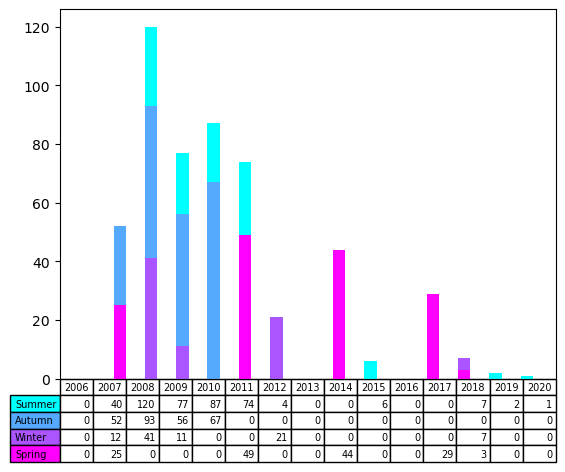

In [22]:
prep4table = lambda season: seasons[season].groupby('time.year').count().dsource.reindex_like(ally,fill_value=0).values
data = [prep4table('summer'),
        prep4table('autumn'),
        prep4table('winter'),
        prep4table('spring')]

# values = np.arange(0, 2500, 500)
# value_increment = 1000
# Get some pastel shades for the colors
colors = plt.cm.cool(np.linspace(0, 1, len(rows)))
n_rows = len(data)
index = np.arange(len(cols)) + 0.3
bar_width = 0.4
# Initialize the vertical-offset for the stacked bar chart.
y_offset = np.zeros(len(cols))
# Plot bars and create text labels for the table
for row in range(n_rows):
    plt.bar(index, data[row], bar_width, bottom=y_offset, color=colors[row])

plt.xticks([])
# Add a table at the bottom of the axes
the_table = plt.table(cellText=data,
                      rowLabels=rows,
                      rowColours=colors,
                      colLabels=cols,
                      loc='bottom')



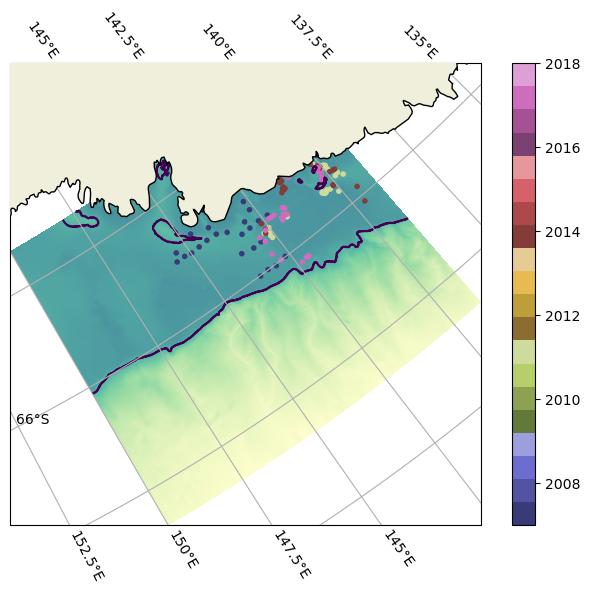

In [23]:
data=seasons['spring']
data['year'] = data.time.dt.year

fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(data.lon,data.lat,c=data.year,transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())
plt.colorbar(im)

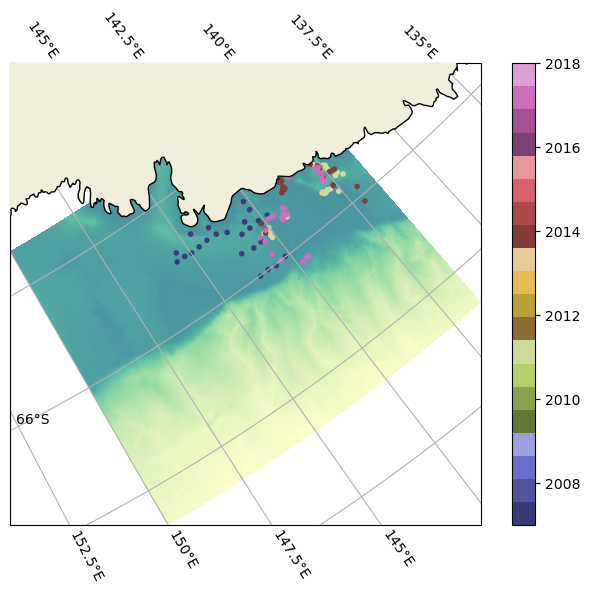

In [24]:
l=-66.5
ss = 'spring'
dss = seasons[ss]#.where(seasons[ss].lat < l,drop=True).where(seasons[ss].lon < 144,drop=True)
#dsw = seasons[ss].where(seasons[ss].lon < l,drop=True)

fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(dss.lon,dss.lat,c=data.year,transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
#im=ax.scatter(dsw.lon,dsw.lat,transform=ccrs.PlateCarree(),marker='.')

plt.colorbar(im)

In [33]:
sanom(sice).where(sice.time.dt.year == 2017,drop=True).mean('time').min()

<xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 8B
array(-0.28343591)

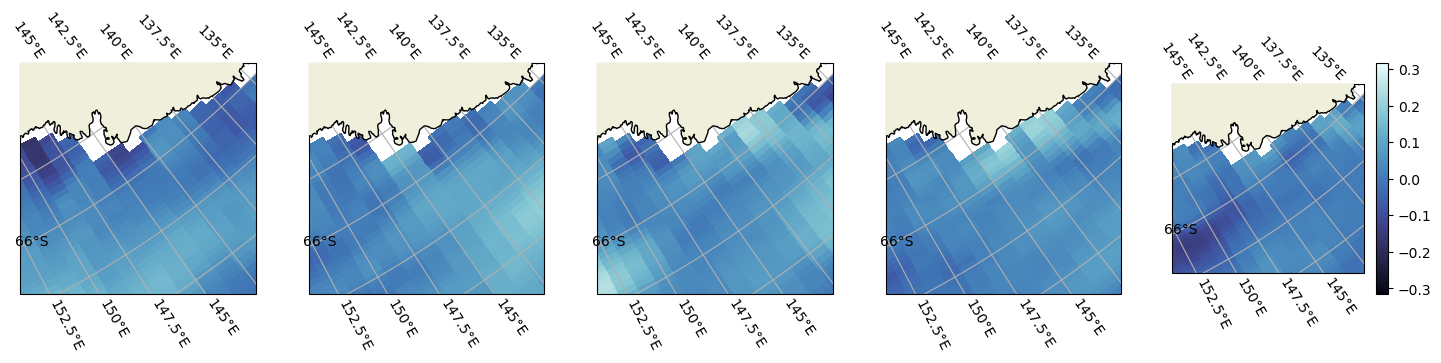

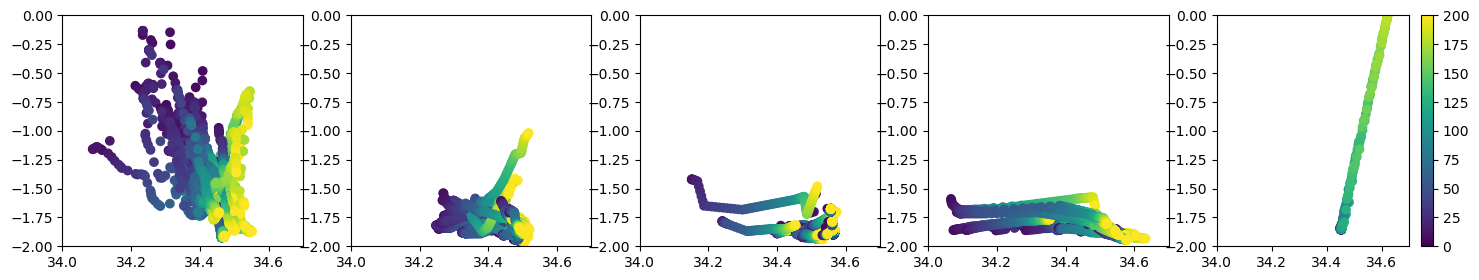

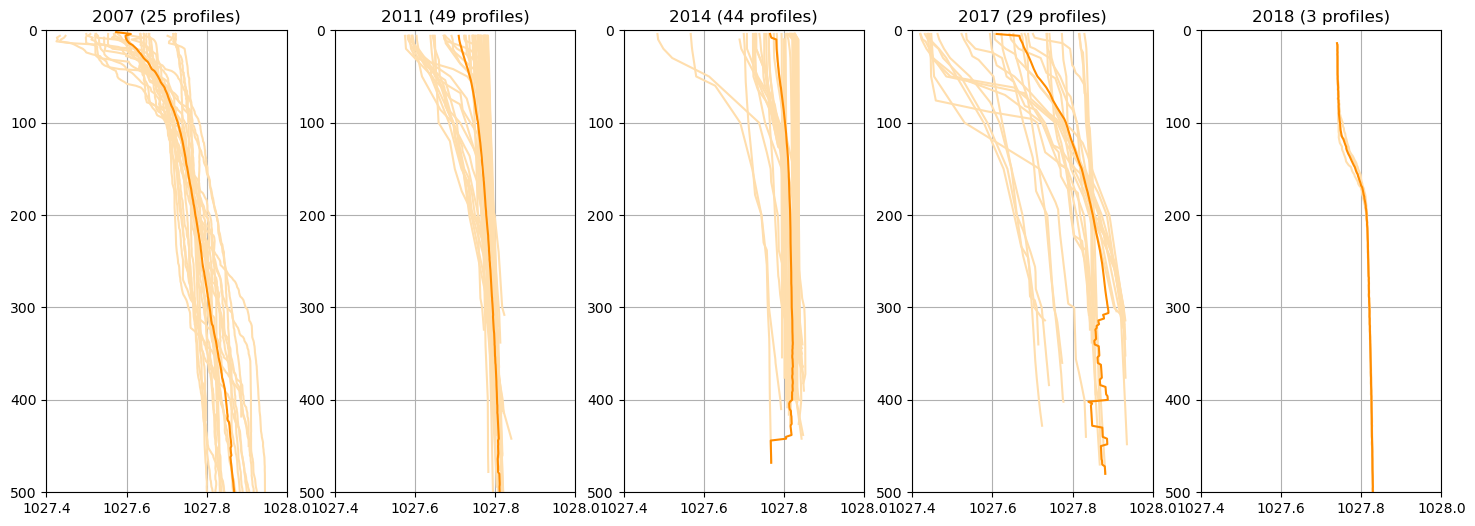

In [ ]:
dse=dss
dse_yr = dse.groupby('time.year').mean()
dse_yr_cnt = dse.groupby('time.year').count()
n = 5


fig1,ax1 = plt.subplots(1,n,figsize=(18,3),subplot_kw={'projection':ccrs.SouthPolarStereo()})
for ,yr in enumerate(dse_yr.year):
    data=sanom(sice).where(sice.time.dt.year == yr,drop=True)
    im=pfns.sp(ax,data.mean('time'),extent=extent,cmap=cmocean.cm.ice,land_zorder=3)
plt.colorbar(im)

fig2,ax2 = plt.subplots(1,n,figsize=(18,3))
for i,yr in enumerate(dse_yr.year):
    data=dse.where(dse.year == yr,drop=True).sel(pres=slice(6,200))
    for p in data.time:
        data_=data.sel(time=p)
        im=ax2[i].scatter(data_.psal,data_.temp,c=data_.pres,vmin=0,vmax=200)
    # ax[i].plot(dse_yr.sel(year=yr).rho,dse_yr.pres,c='darkorange')
    # ax[i].set_title(str(yr.item()) + ' ({} profiles)'.format(dse_yr_cnt.sel(year=yr).dsource.item()))
    # ax[i].grid()
    ax[i].set_xlim([34,34.7])
    ax[i].set_ylim([-2,0])
    # ax[i].invert_yaxis()
plt.colorbar(im)

fig,ax = plt.subplots(1,n,figsize=(18,6))
for i,yr in enumerate(dse_yr.year):
    data=dse.where(dse.year == yr,drop=True)
    for p in data.time:
        data_=data.sel(time=p)
        ax[i].plot(data_.rho,data.pres,c='navajowhite')
    ax[i].plot(dse_yr.sel(year=yr).rho,dse_yr.pres,c='darkorange')
    ax[i].set_title(str(yr.item()) + ' ({} profiles)'.format(dse_yr_cnt.sel(year=yr).dsource.item()))
    ax[i].grid()
    ax[i].set_xlim([1027.4,1028])
    ax[i].set_ylim([0,500])
    ax[i].invert_yaxis()

# dsw_yr = dsw.groupby('time.year').mean()
# dsw_yr_cnt = dsw.groupby('time.year').count()

# fig,ax = plt.subplots(1,8,figsize=(18,6))
# for i,yr in enumerate(dsw_yr.year):
#     data=dsw.where(dsw.year == yr,drop=True)
#     for p in data.time:
#         data_=data.sel(time=p)
#         ax[i].plot(data_.rho,data.pres,c='navajowhite')
#     ax[i].plot(dsw_yr.sel(year=yr).rho,dsw_yr.pres,c='darkorange')
#     ax[i].set_title(str(yr.item()) + ' ({} profiles)'.format(dsw_yr_cnt.sel(year=yr).dsource.item()))
#     ax[i].invert_yaxis()
#     ax[i].grid()
#     ax[i].set_xlim([1027,1028])

    

In [ ]:
data.mean('time'),extent=extent,cmap=cmocean.cm.ice,land_zorder=3)
plt.colorbar(im)

for ax,yr in zip(ax2,dse_yr.year):
    
    for p in data.time:
        data_=data.sel(time=p)
        im=ax.scatter(data_.psal,data_.temp,c=data_.pres,vmin=0,vmax=200)
    ax.set_xlim([34,34.7])
    ax.set_ylim([-2,0])
plt.colorbar(im)

for ax,yr in zip(ax3,dse_yr.year):
    data=dse.where(dse.year == yr,drop=True)
    for p in data.time:
        data_=data.sel(time=p)
        ax.plot(data_.rho,data.pres,c='navajowhite')
    ax.plot(dse_yr.sel(year=yr).rho,dse_yr.pres,c='darkorange')
    ax.set_title(str(yr.item()) + ' ({} profiles)'.format(dse_yr_cnt.sel(year=yr).dsource.item()))
    ax.grid()
    ax.set_xlim([1027.4,1028])
    ax.set_ylim([0,500])
    ax.invert_yaxis()


    

In [33]:
dse.where(dse.year==2017,drop=True).isel(pres=3).rho

<xarray.DataArray 'rho' (time: 20)> Size: 80B
array([1027.5945, 1027.644 , 1027.653 , 1027.7355, 1027.6742, 1027.7362,
       1027.7737, 1027.7427, 1027.6896, 1027.6829, 1027.8177, 1027.8168,
       1027.8303, 1027.7034, 1027.623 , 1027.438 , 1027.4479, 1027.4434,
       1027.4213, 1027.4225], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 160B 2017-11-14T15:30:00.000003 ... 2017-1...
    pres     int64 8B 6
    lon      (time) float64 160B 141.7 142.2 141.8 142.0 ... 142.1 142.1 142.1
    lat      (time) float64 160B -66.49 -66.51 -66.52 ... -65.83 -65.83 -65.83
    n_prof   (time) float64 160B 7.932e+05 7.932e+05 ... 7.932e+05 7.932e+05
Attributes:
    long_name:      In-situ Density
    standard_name:  rho
    units:          kg/m^-3

In [32]:
dsw.where(dsw.year==2017,drop=True).isel(pres=3).rho

<xarray.DataArray 'rho' (time: 9)> Size: 36B
array([1027.5352, 1027.6051, 1027.5251, 1027.4342, 1027.4409, 1027.4647,
       1028.164 , 1028.1091, 1028.1913], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 72B 2017-11-09T21:30:00.000003 ... 2017-12...
    pres     int64 8B 6
    lon      (time) float64 72B 140.1 140.1 140.2 140.2 ... 140.2 140.2 141.0
    lat      (time) float64 72B -66.62 -66.63 -66.6 ... -66.55 -66.62 -66.77
    n_prof   (time) float64 72B 7.932e+05 7.932e+05 ... 5.99e+05 5.99e+05
Attributes:
    long_name:      In-situ Density
    standard_name:  rho
    units:          kg/m^-3

In [42]:
ds_shelf.rho.where(ds_shelf.rho > 1028,drop=True)

<xarray.DataArray 'rho' (time: 9, pres: 322)> Size: 12kB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [1028.164 , 1028.1647, 1028.1654, ...,       nan,       nan,
              nan],
       [1028.1091, 1028.1112, 1028.1133, ...,       nan,       nan,
              nan],
       [1028.1913, 1028.1936, 1028.1959, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
    lon      (time) float64 72B 141.2 141.1 141.1 141.1 ... 140.2 140.2 141.0
    lat      (time) float64 72B -66.54 -66.78 -66.59 ... -66.55 -66.62 -66.77
  * time     (time) datetime64[ns] 72B 2007-06-28T02:39:58.999996 ... 2017-12...
    n_prof   (time) int64 72B 793301 673587 673562 ... 598956 598957 598958
  * pres     (pres) int64 3kB 6 8 10 12 14 16 18 ... 754 756 758 760 762 764 766
Attributes:
    long_name:      In-situ Density
    standard_name:  rho
    units:          kg/m^-3

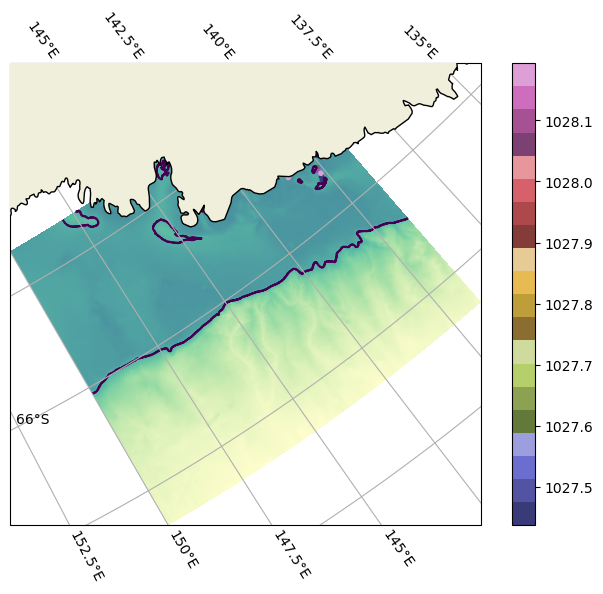

In [38]:
data = dsw.where(dsw.year==2017,drop=True)
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(data.lon,data.lat,c=data.rho.isel(pres=4),transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())
plt.colorbar(im)

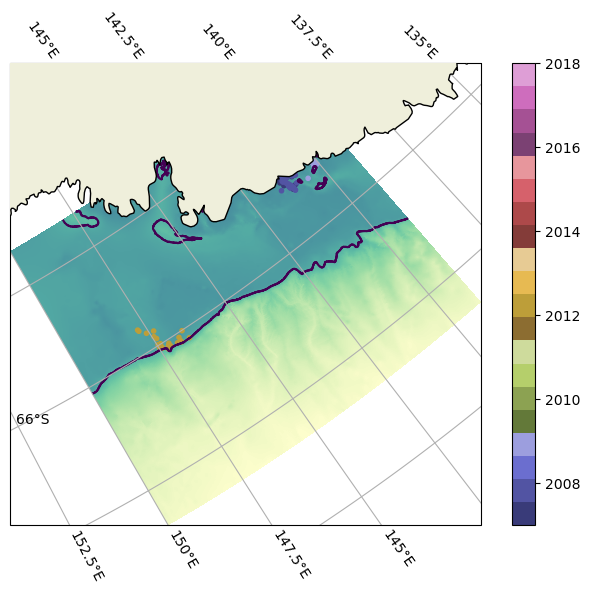

In [55]:
ssn=seasons['winter']
ssn['year'] = ssn.time.dt.year

fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(ssn.lon,ssn.lat,c=ssn.year,transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())
plt.colorbar(im)

In [87]:
data_.to_dataframe()

,temp,psal,dsource,mld,asal,ctemp,rho,mlp,elevation,month,year,lon,lat,time,n_prof
pres,,,,,,,,,,,,,,,
0,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
2,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
4,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
6,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
8,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,0.335580,34.682620,SOCCOM,118.771225,34.849487,0.336616,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
994,0.335046,34.682561,SOCCOM,118.771225,34.849426,0.336083,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
996,0.334511,34.682501,SOCCOM,118.771225,34.849369,0.335549,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118


ValueError: cannot handle a non-unique multi-index!

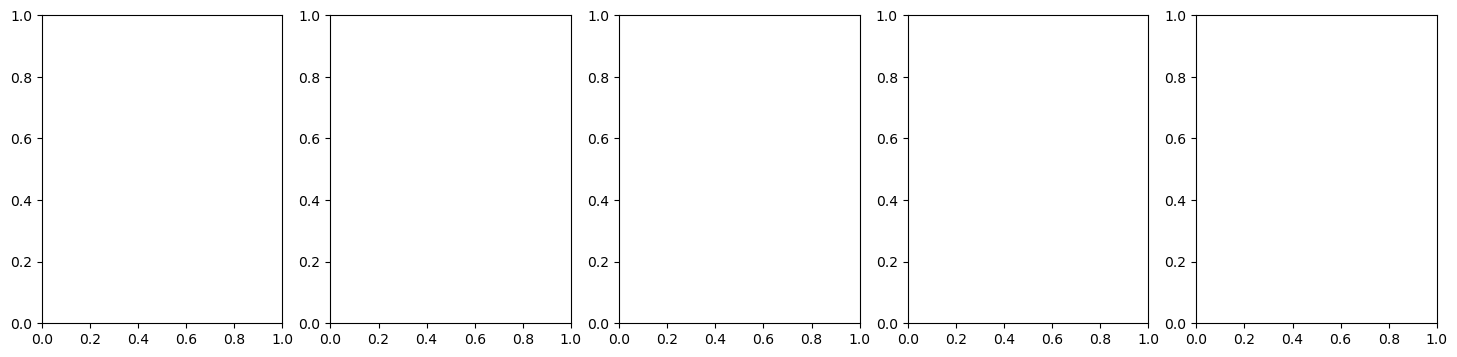

In [90]:
ds_yr = ssn.groupby('time.year').mean()
ds_yr_cnt = ssn.groupby('time.year').count()

fig,ax = plt.subplots(1,len(ds_yr.year),figsize=(18,4))
for i,yr in enumerate(ds_yr.year):
    data_=ssn.where(ssn.year == yr,drop=True)
    sns.kdeplot(ax=ax[i],data=data_.to_dataframe(),x='psal',y='temp')

fig,ax = plt.subplots(1,len(ds_yr.year),figsize=(18,6))

for i,yr in enumerate(ds_yr.year):
    data=ssn.where(ssn.year == yr,drop=True)
    for p in data.time:
        data_=data.sel(time=p)
        try:
            ax[i].plot(data_.rho,data.pres,c='navajowhite')
        except:
            for l in data_.lat:
                ax[i].plot(data_.rho.swap_dims({'time':'lat'}).sel(lat=l),data.pres,c='navajowhite')
    ax[i].plot(ds_yr.sel(year=yr).rho,ds_yr.pres,c='darkorange')
    ax[i].set_title(str(yr.item()) + ' ({} profiles)'.format(ds_yr_cnt.sel(year=yr).dsource.item()))
    ax[i].invert_yaxis()
    ax[i].grid()
    ax[i].set_xlim([1027.4,1028.4])
    ax[i].set_ylim([0,600])

preparing lag=0 months
preparing data
plotting..
preparing lag=1 months
preparing data
plotting..
preparing lag=2 months
preparing data
plotting..
preparing lag=3 months
preparing data
plotting..
preparing lag=4 months
preparing data
plotting..
preparing lag=5 months
preparing data
plotting..
preparing lag=6 months
preparing data
plotting..


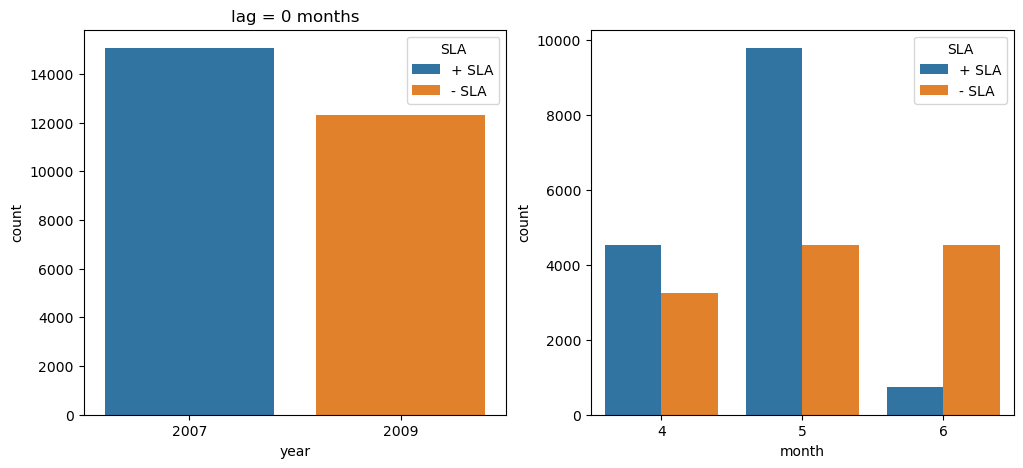

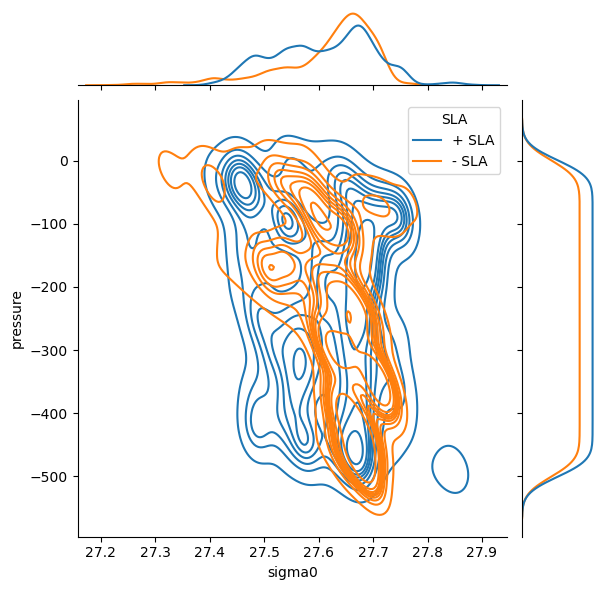

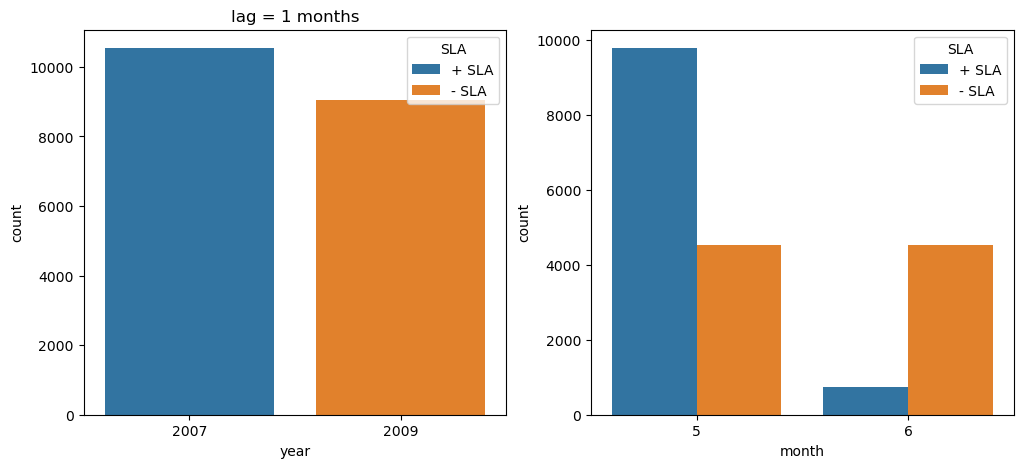

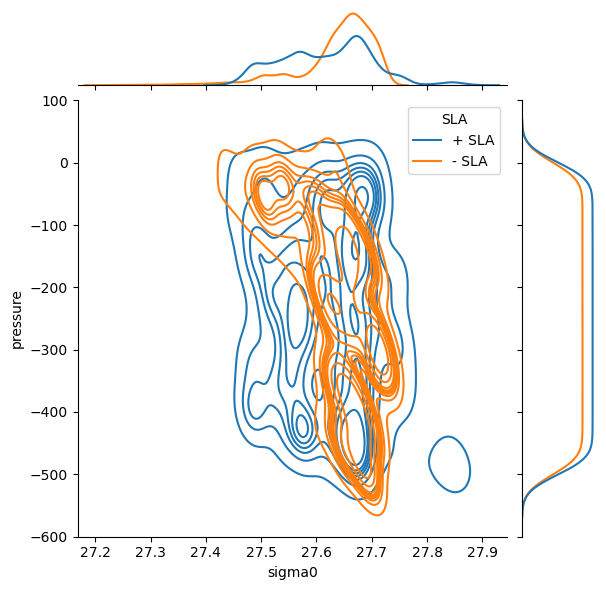

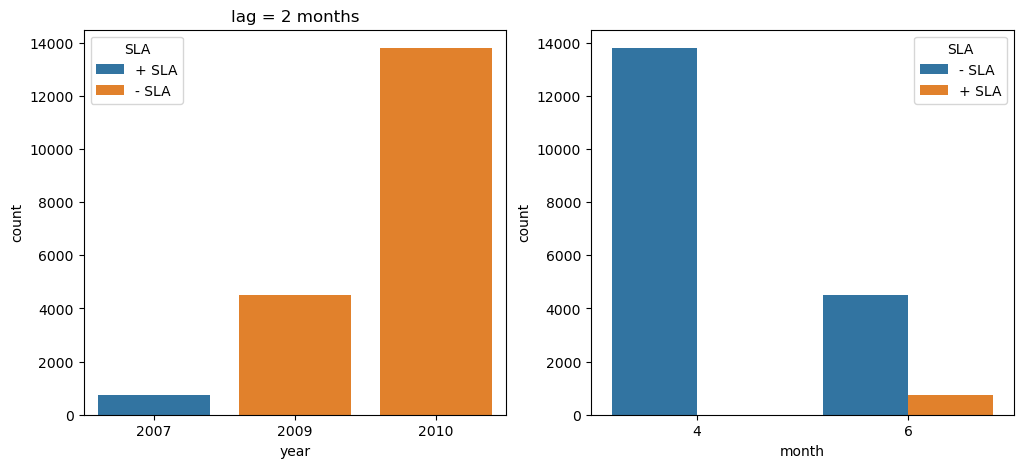

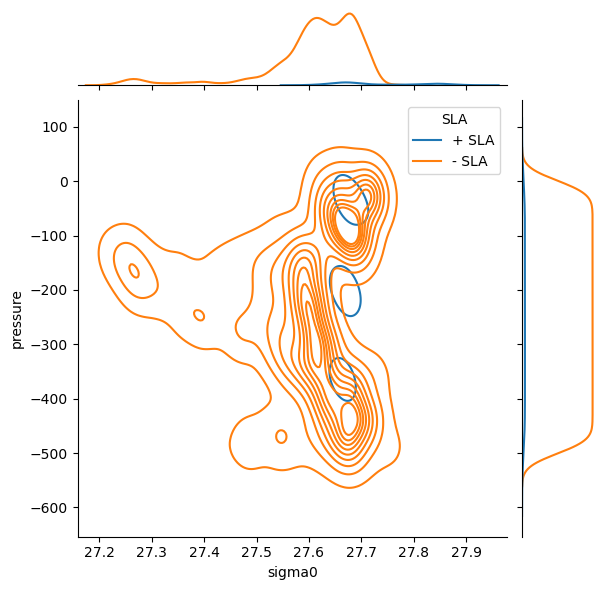

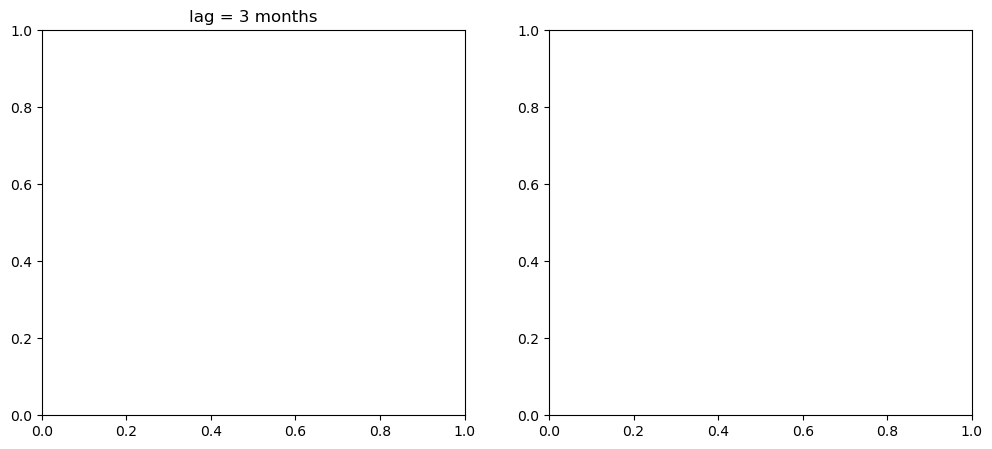

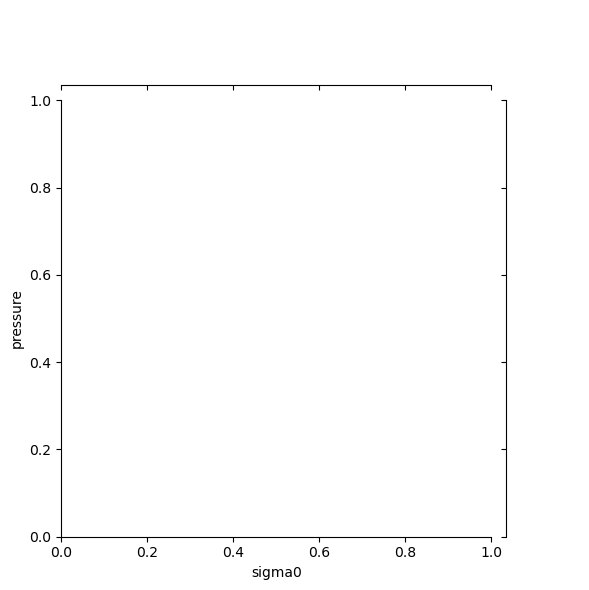

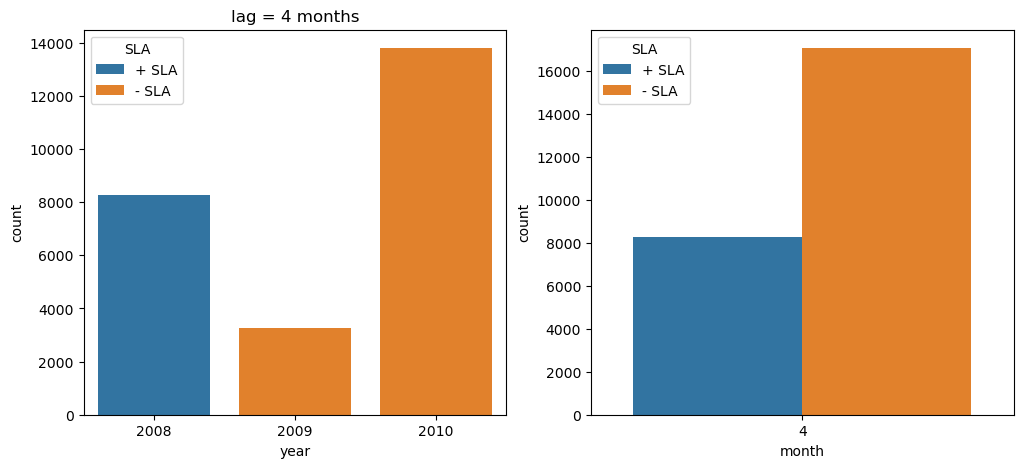

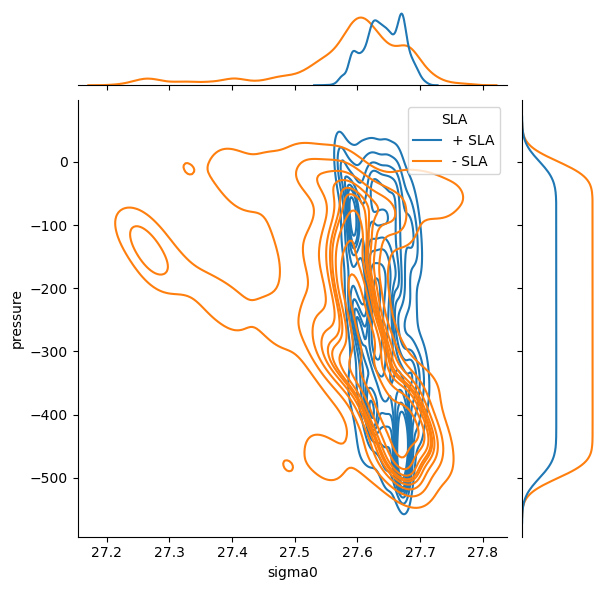

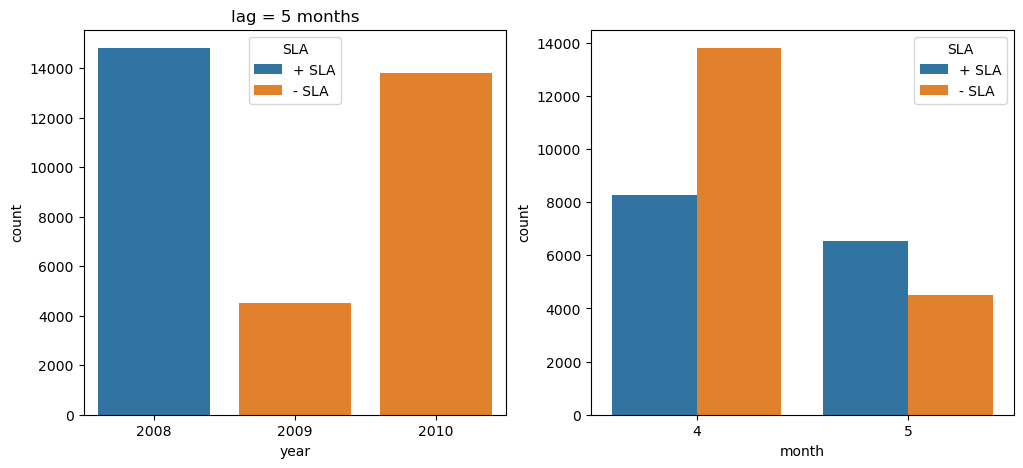

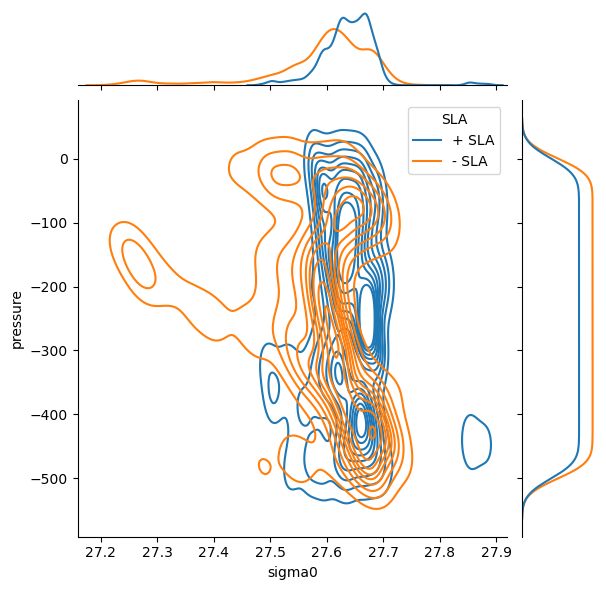

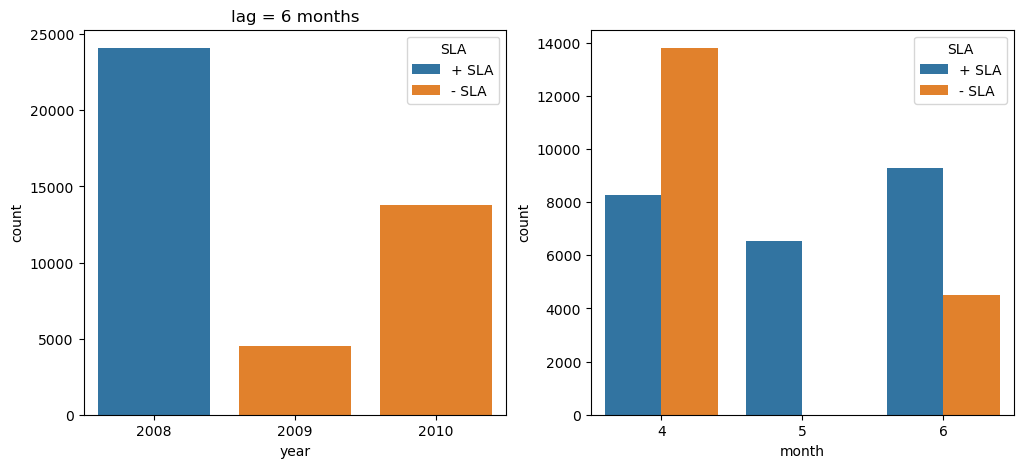

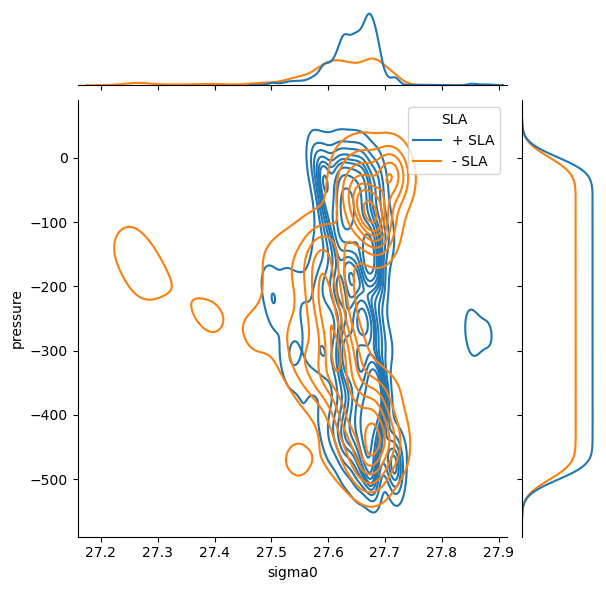

In [ ]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

for l in np.arange(7):
    print('preparing lag={} months'.format(l))
    cmp = Composite(idx_data,'SLA')
    cmp.add_spira(seasons['autumn'],tlims=tlims,slims=slims,lag=l)
    cmp.build_sns_data()

    fig, ax = plt.subplots(1,2,figsize=(12,5))
    sns.countplot(cmp.sns_data, x='year', hue='SLA',ax=ax[0])
    sns.countplot(cmp.sns_data, x='month', hue='SLA',ax=ax[1])
    ax[0].set_title('lag = {} months'.format(l))

    print('plotting..')
    g = sns.JointGrid(data=cmp.sns_data, x='sigma0', y ='pressure', hue='SLA')
    g.plot(sns.kdeplot, sns.kdeplot)

In [32]:
cmp = Composite(idx_data,'SLA')
cmp.add_spira(seasons['autumn'],tlims=tlims,slims=slims,lag=4)
cmp.build_sns_data()

preparing data


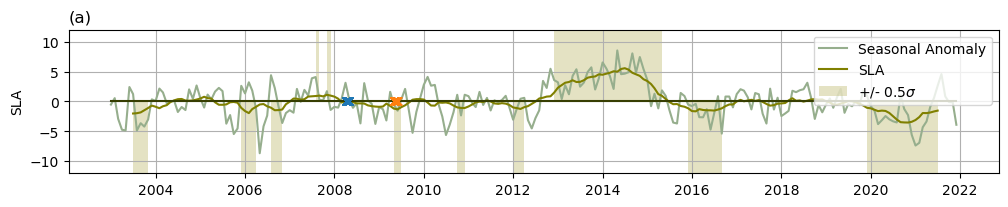

In [33]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')

ValueError: x and y must have same first dimension, but have shapes (2, 251) and (251,)

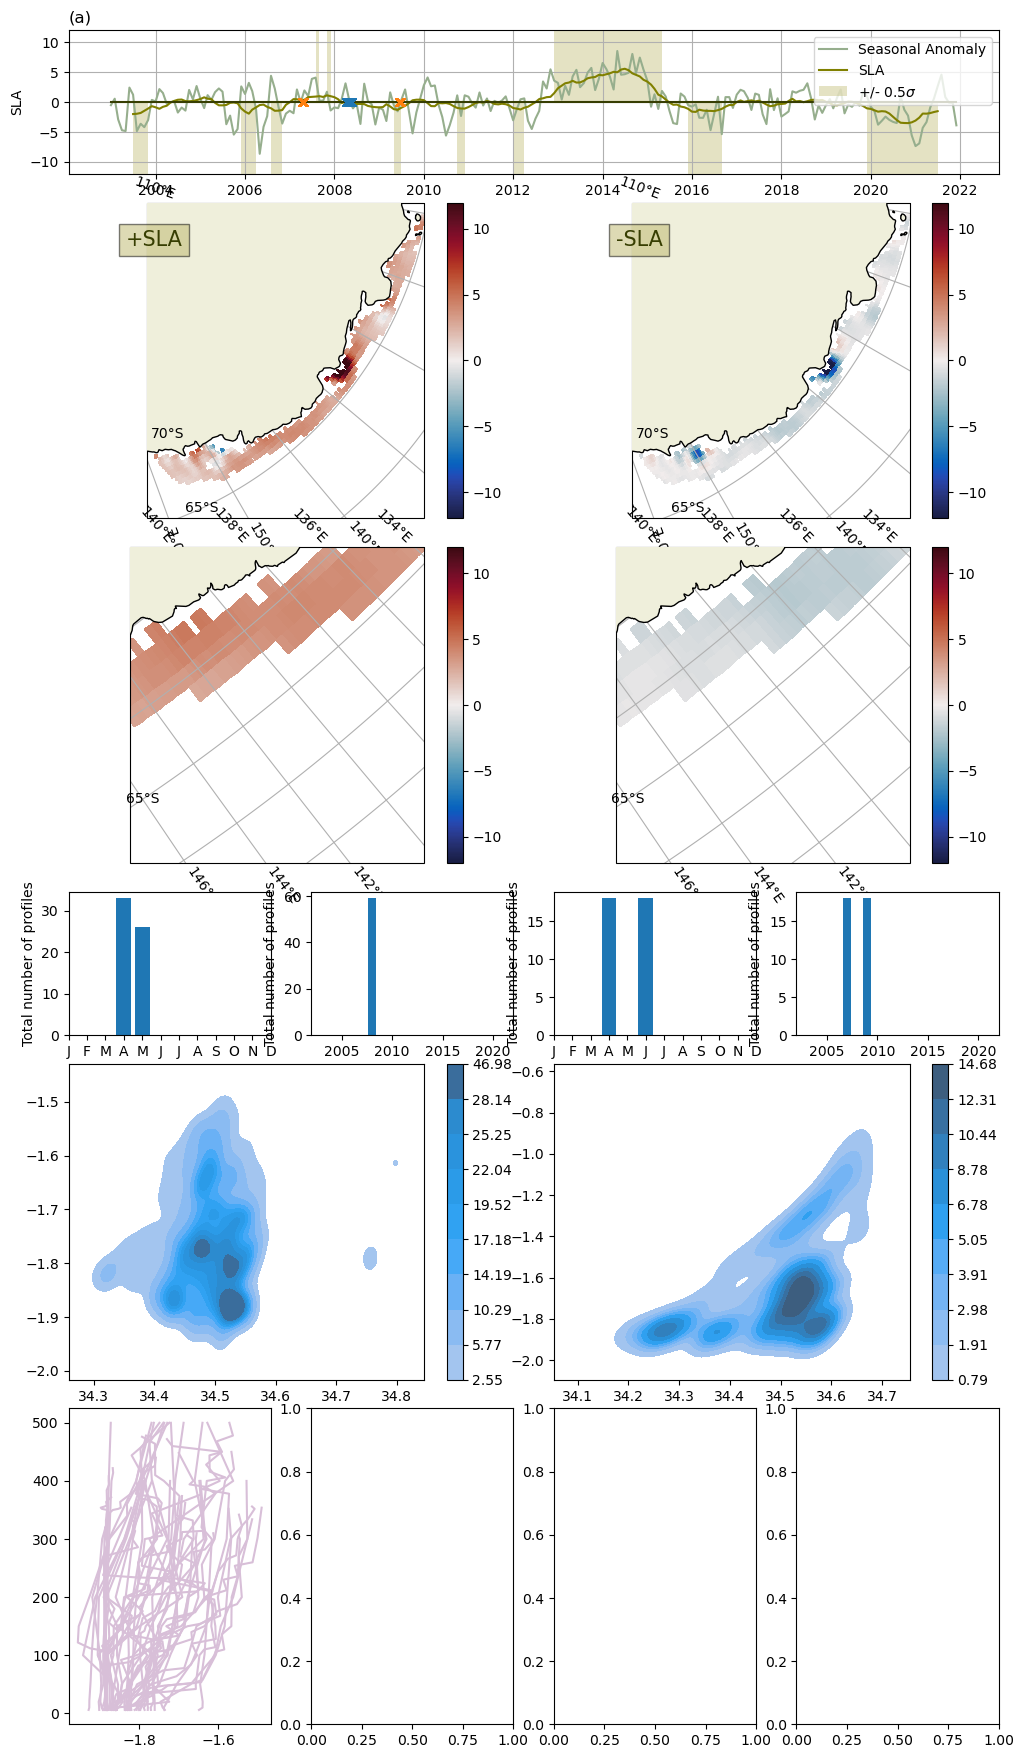

In [29]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
# cmp.ts_density([
    # fig.add_subplot(gs[n:n+2,0:2]),
    # fig.add_subplot(gs[n:n+2,2:4])
    # ])

ax6 = fig.add_subplot(gs[n:n+2,0:2])
ax7 = fig.add_subplot(gs[n:n+2,2:4])

sns.kdeplot(ax=ax6,x=cmp.s_pos.values.flatten(), y=cmp.t_pos.values.flatten(), fill=True, cbar=True)
sns.kdeplot(ax=ax7, x=cmp.s_neg.values.flatten(), y=cmp.t_neg.values.flatten(),fill=True, cbar=True)

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



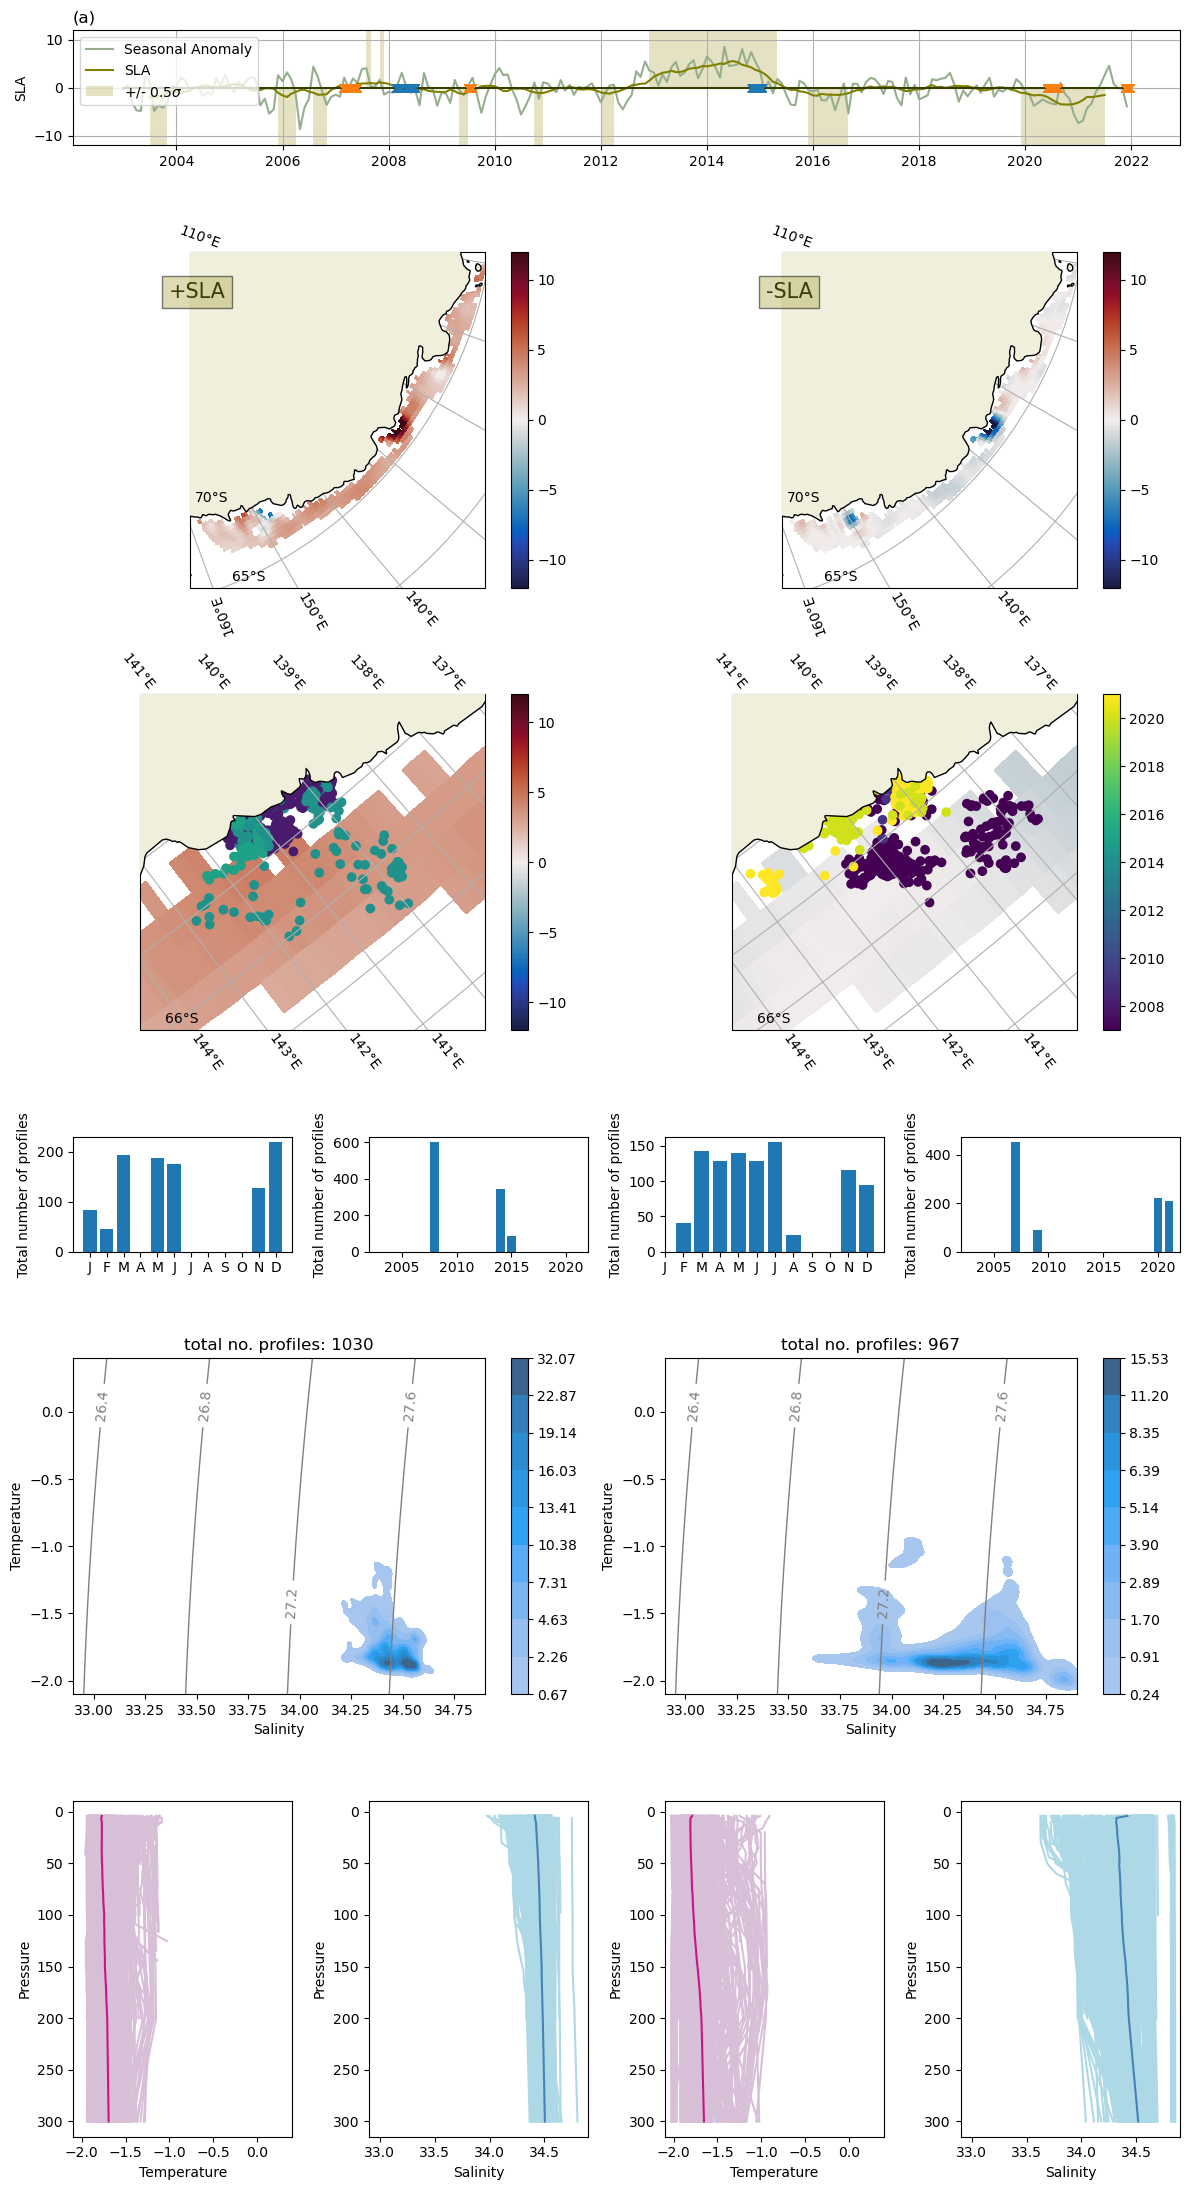

In [ ]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [18]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()

In [22]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

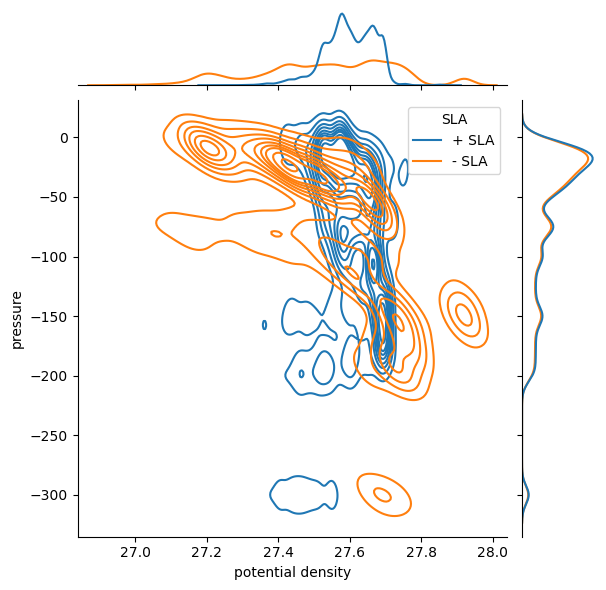

In [23]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [24]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=2)

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


In [26]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]

In [27]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

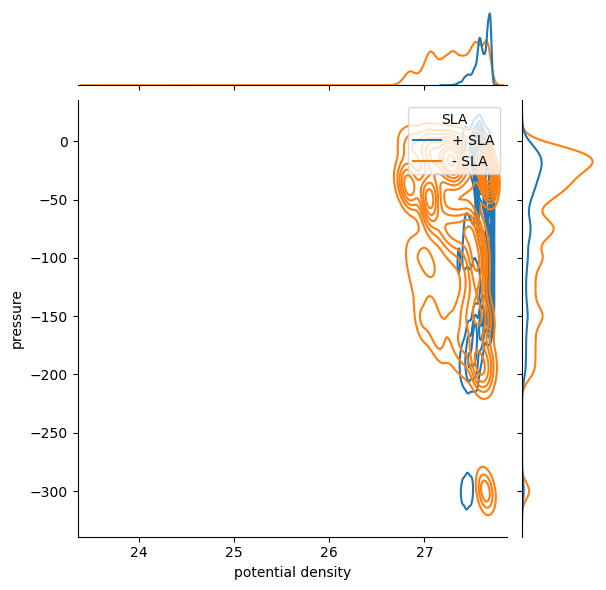

In [28]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [29]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=3)
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


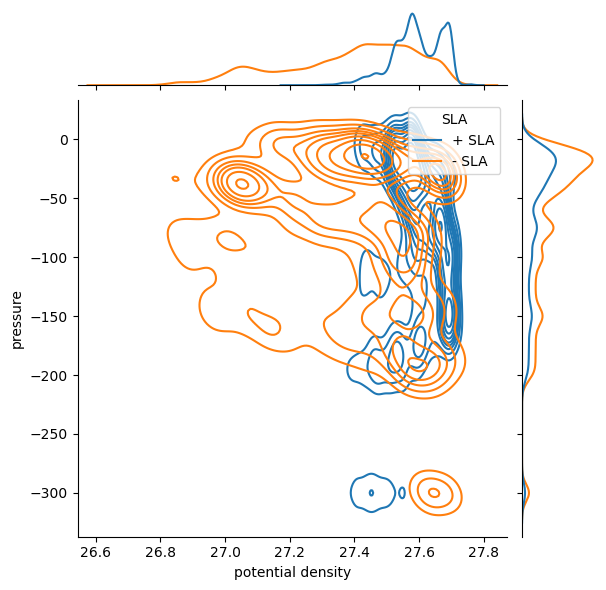

In [30]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)